# Sentiment Analysis — Airline Customer Tweets
**Oasis Infobyte Internship · Data Analytics · Level 1 — Task 4**<br>
**Author:** Ojewumi Asaph Felix

**Objective:** build a machine learning model that classifies the sentiment of customer messages as **positive, negative or neutral**, and use it to understand what customers complain about.

**Dataset:** *Twitter US Airline Sentiment* (Figure Eight / Kaggle, CC BY-NC-SA 4.0) — 14,640 tweets sent to 6 US airlines in February 2015, each labelled by human annotators.

> **Key results**
> - The best models (**Logistic Regression and Linear SVM**) reach **≈ 79 % accuracy** on unseen tweets, vs. 63 % for always predicting "negative" and 45 % for the rule-based TextBlob.
> - **Negative tweets are recognised very well** (F1 ≈ 0.88); **neutral** tweets are the hardest class.
> - **63 % of tweets are negative**, mainly about **customer service** and **late flights**.

**Contents**
1. Data loading and class distribution
2. Text preprocessing
3. Feature extraction: TF-IDF
4. Train / test split
5. Model training
6. Evaluation
7. Visualisations: word clouds and sentiment by airline
8. Error analysis
9. Conclusion

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap
from nltk.stem import PorterStemmer
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", "{:,.3f}".format)

BLUE, ORANGE, GREY, INK, MUTED = "#2a78d6", "#eb6834", "#b9b8b3", "#0b0b0b", "#52514e"
CLASSES = ["negative", "neutral", "positive"]
COLORS = {"negative": ORANGE, "neutral": GREY, "positive": BLUE}
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#cfcecb", "axes.labelcolor": MUTED, "axes.titleweight": "bold",
    "axes.titlesize": 12.5, "axes.titlecolor": INK, "axes.titlelocation": "left", "axes.titlepad": 12,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.grid": True, "grid.color": "#ecebe8", "grid.linewidth": 0.8, "axes.axisbelow": True,
})

## 1. Data Loading and Class Distribution

In [2]:
raw = pd.read_csv("data/Tweets.csv")
print("Shape:", raw.shape)
raw[["tweet_id", "airline", "airline_sentiment", "negativereason", "text"]].head()

Shape: (14640, 15)


,tweet_id,airline,airline_sentiment,negativereason,text
0,570306133677760513,Virgin America,neutral,NaN,@VirginAmerica What @dhepburn said.
1,570301130888122368,Virgin America,positive,NaN,@VirginAmerica plus you've added commercials to the experience... tacky.
2,570301083672813571,Virgin America,neutral,NaN,@VirginAmerica I didn't today... Must mean I need to take another trip!
3,570301031407624196,Virgin America,negative,Bad Flight,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have little recourse"
4,570300817074462722,Virgin America,negative,Can't Tell,@VirginAmerica and it's a really big bad thing about it


In [3]:
print("Duplicated tweet IDs:", raw["tweet_id"].duplicated().sum())
df = raw.drop_duplicates("tweet_id").reset_index(drop=True)
print("Tweets after removing duplicates:", len(df))

counts = df["airline_sentiment"].value_counts().reindex(CLASSES)
pd.DataFrame({"tweets": counts, "share": counts / counts.sum()})

Duplicated tweet IDs: 155
Tweets after removing duplicates: 14485


,tweets,share
airline_sentiment,,
negative,9082,0.627
neutral,3069,0.212
positive,2334,0.161


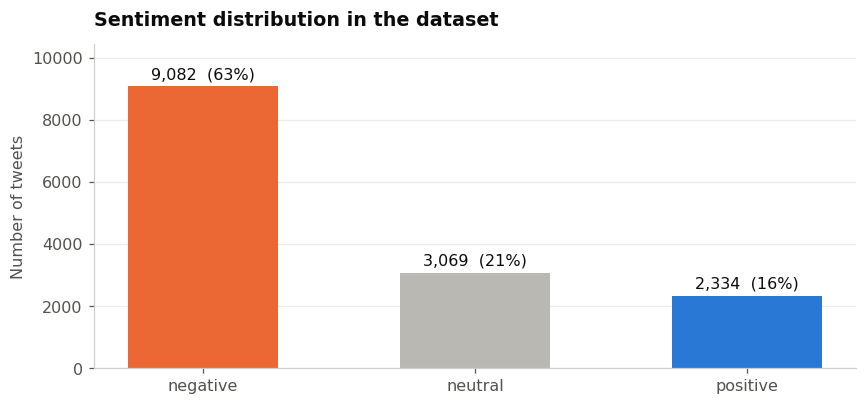

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(counts.index, counts.values, color=[COLORS[c] for c in counts.index], width=0.55)
ax.bar_label(bars, labels=[f"{v:,}  ({v / counts.sum():.0%})" for v in counts.values], padding=3, color=INK)
ax.set_title("Sentiment distribution in the dataset")
ax.set_ylabel("Number of tweets")
ax.set_ylim(0, counts.max() * 1.15)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.savefig("images/sentiment_distribution.png")
plt.show()

**Observations:**
- 155 tweets appeared twice with the same ID and were removed.
- The classes are **imbalanced**: **63 % negative**, 21 % neutral and only 16 % positive. Customers mostly tweet at airlines to complain.
- Consequence: **accuracy alone is misleading** — a model that always answers "negative" would already reach 63 %. We will also look at **precision, recall and F1-score per class**.

## 2. Text Preprocessing
Raw tweets contain mentions (`@united`), links, punctuation, numbers and very common words that carry no sentiment. The pipeline:
1. **Lowercase**
2. Remove **links** and **@mentions** (the airline name is not a sentiment)
3. Fix a known artefact of this dataset (*"Cancelled Flightled"*, *"Late Flightr"* → *"cancelled flight"*, *"late flight"*) and turn contractions like `don't`, `can't`, `won't` into `do not`, `can not`, `will not`
4. Remove **punctuation and numbers**
5. **Tokenise** (split into words)
6. Remove **stopwords** — but **keep negations** (`not`, `no`, `never`…): *"not good"* and *"good"* have opposite meanings
7. **Stemming** with the Porter stemmer (`delayed`, `delays` → `delay`)

In [5]:
NEGATIONS = {"no", "not", "nor", "never", "cannot", "cant", "nothing", "none", "against",
             "very", "too", "down", "off", "over"}
STOPWORDS = set(ENGLISH_STOP_WORDS) - NEGATIONS
stemmer = PorterStemmer()

def tokenize(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)       # links
    text = re.sub(r"@\w+", " ", text)                    # mentions
    text = re.sub(r"\bflight(led|ed|r|d|ing|ling|lations?)\b", "flight", text)             # dataset artefact
    text = text.replace("can't", "can not").replace("won't", "will not").replace("n't", " not")
    text = re.sub(r"[^a-z\s]", " ", text)                 # punctuation, numbers, emojis
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 1]

df["tokens"] = df["text"].apply(tokenize)
df["clean_text"] = df["tokens"].apply(" ".join)                             # readable (word clouds)
df["stemmed"] = df["tokens"].apply(lambda t: " ".join(stemmer.stem(w) for w in t))  # model input

df[["text", "clean_text", "stemmed"]].sample(5, random_state=3)

,text,clean_text,stemmed
13433,@AmericanAir all I want is to know what to do regarding my connecting flights since my 1st is Cancelled Flightled. Could you be of assis...,want know regarding connecting flights st cancelled flight assistance,want know regard connect flight st cancel flight assist
1446,@united customers aren't dumb. These revenue based programs will hurt everyone. Not gonna save money like you think,customers not dumb revenue based programs hurt not gonna save money like think,custom not dumb revenu base program hurt not gonna save money like think
4122,@united @gg8929 so why did you Cancelled Flight tickets for thousands of people when you didn't like the exchange rate? #doublestandards,did cancelled flight tickets thousands people did not like exchange rate doublestandards,did cancel flight ticket thousand peopl did not like exchang rate doublestandard
11331,@USAirways I wish we were on our way. Now there's a problem w/de-icing.Three &amp; 1/2 hour delay so far &amp; sill not sure if we'll be...,wish way problem icing amp hour delay far amp sill not sure ll taking off,wish way problem ice amp hour delay far amp sill not sure ll take off
13348,@AmericanAir wasn't just a delay. Your counter wouldn't take a valid CAC card as a valid ID which is needed for a TSA precheck on pass,not just delay counter not valid cac card valid id needed tsa precheck pass,not just delay counter not valid cac card valid id need tsa precheck pass


**Observation:** the cleaned text keeps only the words that carry meaning (e.g. *"flight cancelled"*, *"not happy"*, *"thanks great"*). Stemming was kept because it slightly improved the results (+0.5 point of accuracy in our tests) by grouping word variants.

## 3. Feature Extraction: TF-IDF
A model cannot read words, it needs numbers. **TF-IDF** (*Term Frequency – Inverse Document Frequency*) turns each tweet into a vector where each word gets a weight:
- **TF**: the more often a word appears in the tweet, the higher its weight;
- **IDF**: the more tweets contain the word, the lower its weight — so very common words like *"flight"* count less than rare, meaningful words like *"rude"* or *"amazing"*.

We use **unigrams and bigrams** (single words and pairs of words), so that expressions such as *"not happy"* or *"customer service"* become features, and ignore words that appear in only one tweet.

## 4. Train / Test Split (80 / 20)

In [6]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["stemmed"], df["airline_sentiment"], test_size=0.2, stratify=df["airline_sentiment"], random_state=42)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train = vectorizer.fit_transform(X_train_text)     # fitted on the training set only
X_test = vectorizer.transform(X_test_text)

print(f"Training set: {X_train.shape[0]:,} tweets")
print(f"Test set    : {X_test.shape[0]:,} tweets")
print(f"Vocabulary  : {X_train.shape[1]:,} features (words and word pairs)")

Training set: 11,588 tweets
Test set    : 2,897 tweets
Vocabulary  : 12,436 features (words and word pairs)


The split is **stratified**, so both sets keep the same 63 / 21 / 16 % proportions. The TF-IDF vocabulary is learned **only on the training set**, to avoid information from the test set leaking into the model.

## 5. Model Training
- **Naive Bayes** (MultinomialNB): fast probabilistic classic for text. Its smoothing parameter `alpha` is tuned with 5-fold cross-validation on the training set.
- **Logistic Regression**: linear model that learns a weight for every word.
- **Linear SVM**: finds the boundary with the largest margin between classes, very effective on sparse text vectors.

Two **baselines** show what "good" means: always predicting the majority class, and **TextBlob**, a rule-based tool that needs no training.

In [7]:
nb_search = GridSearchCV(MultinomialNB(), {"alpha": [0.05, 0.1, 0.3, 1.0]}, cv=5, scoring="f1_macro")
nb_search.fit(X_train, y_train)
print("Best alpha for Naive Bayes:", nb_search.best_params_["alpha"])

models = {
    "Naive Bayes": nb_search.best_estimator_,
    "Logistic Regression": LogisticRegression(C=3, max_iter=2000),
    "Linear SVM": LinearSVC(C=0.5),
}
predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)

# Baselines
predictions["Baseline: always 'negative'"] = np.full(len(y_test), "negative")
polarity = df.loc[y_test.index, "text"].apply(lambda t: TextBlob(t).sentiment.polarity)
predictions["Baseline: TextBlob (rules)"] = np.where(polarity > 0.05, "positive",
                                                     np.where(polarity < -0.05, "negative", "neutral"))

Best alpha for Naive Bayes: 0.1


## 6. Evaluation

In [8]:
results = pd.DataFrame({
    name: {
        "accuracy": accuracy_score(y_test, p),
        "precision (macro)": precision_score(y_test, p, average="macro", zero_division=0),
        "recall (macro)": recall_score(y_test, p, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, p, average="macro", zero_division=0),
    } for name, p in predictions.items()
}).T.sort_values("F1 (macro)", ascending=False)
results

,accuracy,precision (macro),recall (macro),F1 (macro)
Logistic Regression,0.793,0.754,0.687,0.714
Linear SVM,0.791,0.753,0.686,0.712
Naive Bayes,0.763,0.744,0.626,0.662
Baseline: TextBlob (rules),0.447,0.512,0.563,0.447
Baseline: always 'negative',0.627,0.209,0.333,0.257


In [9]:
for name in models:
    print(f"==== {name} ====")
    print(classification_report(y_test, predictions[name], digits=3))

==== Naive Bayes ====
              precision    recall  f1-score   support

    negative      0.775     0.947     0.852      1816
     neutral      0.646     0.375     0.474       614
    positive      0.810     0.557     0.660       467

    accuracy                          0.763      2897
   macro avg      0.744     0.626     0.662      2897
weighted avg      0.753     0.763     0.741      2897

==== Logistic Regression ====
              precision    recall  f1-score   support

    negative      0.829     0.933     0.878      1816
     neutral      0.650     0.520     0.577       614
    positive      0.785     0.608     0.685       467

    accuracy                          0.793      2897
   macro avg      0.754     0.687     0.714      2897
weighted avg      0.784     0.793     0.783      2897

==== Linear SVM ====
              precision    recall  f1-score   support

    negative      0.825     0.930     0.874      1816
     neutral      0.654     0.513     0.575       614
  

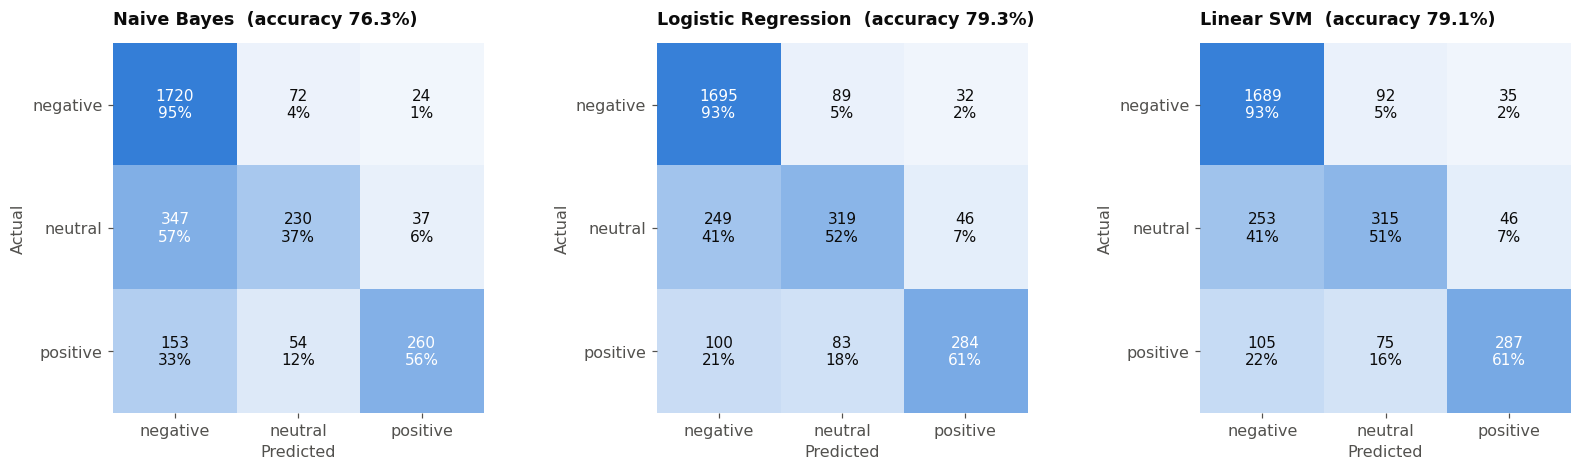

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
cmap = LinearSegmentedColormap.from_list("blues", ["#f4f8fd", BLUE])
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, predictions[name], labels=CLASSES)
    ax.imshow(cm / cm.sum(axis=1, keepdims=True), cmap=cmap, vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            share = cm[i, j] / cm[i].sum()
            ax.text(j, i, f"{cm[i, j]}\n{share:.0%}", ha="center", va="center",
                    color="white" if share > 0.55 else INK, fontsize=10)
    ax.set_xticks(range(3), CLASSES)
    ax.set_yticks(range(3), CLASSES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name}  (accuracy {accuracy_score(y_test, predictions[name]):.1%})", fontsize=11.5)
    ax.grid(False)
    for s in ax.spines.values():
        s.set_visible(False)
plt.tight_layout()
plt.savefig("images/confusion_matrices.png")
plt.show()

**Observations:**
- **Logistic Regression and Linear SVM are the best models (≈ 79 % accuracy, macro F1 ≈ 0.71)** and perform almost identically. Naive Bayes is a little behind.
- All three models are **far better than the baselines**: +16 points over always answering "negative", and TextBlob (≈ 45 %) is not even better than that — a general-purpose rule-based tool does not understand airline-specific complaints such as *"Cancelled Flighted"* or *"on hold for 2 hours"*.
- The **negative** class is recognised best (recall ≈ 0.9). **Neutral** is the weakest class: neutral tweets are often questions (*"what is the baggage fee?"*) whose vocabulary is close to that of complaints.
- The matrices show that most errors are between **neutral and the other two classes**; confusions between positive and negative are rare.

## 7. Visualisations
### 7.1 Word clouds per sentiment

A cloud of the **most frequent** words would look almost the same for every class (*not, flight, thank, time…* appear everywhere). Instead, each word is sized by how **characteristic** it is of the class: its frequency in the class × the log of how much more often it appears in this class than in the others (words used at least 15 times).

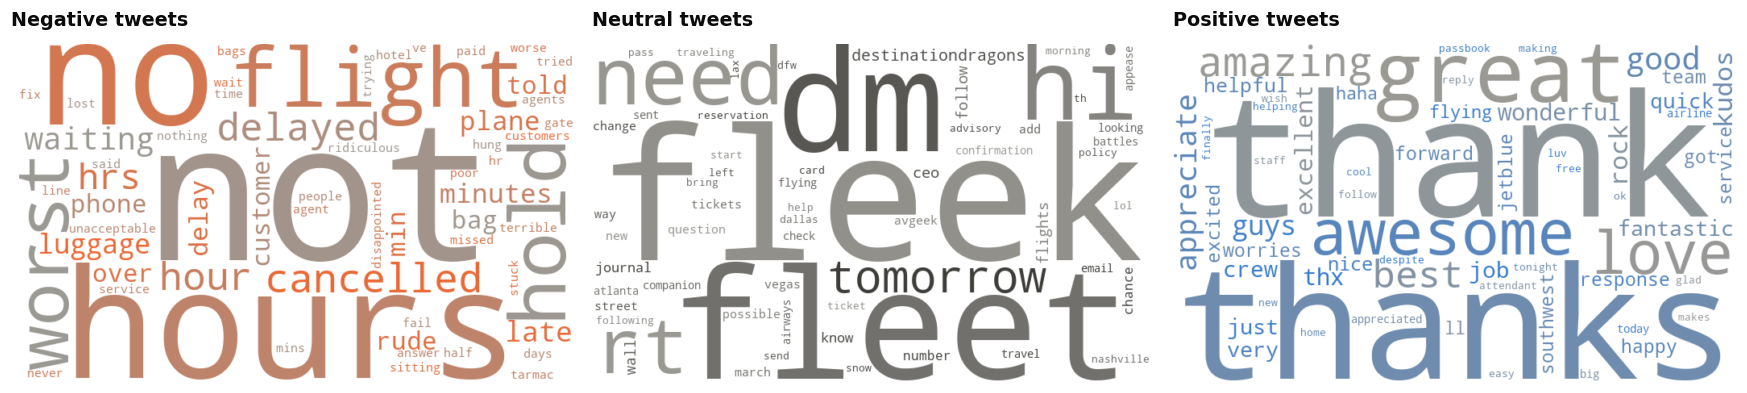

In [11]:
from collections import Counter
freq = {label: Counter(w for toks in df.loc[df["airline_sentiment"] == label, "tokens"] for w in toks) for label in CLASSES}
totals = {label: sum(c.values()) for label, c in freq.items()}

def distinctive(label, min_count=15):
    other = sum((freq[o] for o in CLASSES if o != label), Counter())
    other_total = sum(totals[o] for o in CLASSES if o != label)
    scores = {}
    for w, n in freq[label].items():
        if n >= min_count and w not in {"amp", "im"}:
            ratio = (n / totals[label]) / ((other[w] + 1) / other_total)
            if ratio > 1:
                scores[w] = n * np.log(ratio)
    return scores

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, label in zip(axes, CLASSES):
    wc = WordCloud(width=700, height=420, background_color="white", max_words=60, random_state=1,
                   colormap=LinearSegmentedColormap.from_list(label, ["#9a9994", COLORS[label] if label != "neutral" else "#3b3a37"]))
    ax.imshow(wc.generate_from_frequencies(distinctive(label)), interpolation="bilinear")
    ax.set_title(f"{label.capitalize()} tweets", color=INK)
    ax.axis("off")
plt.tight_layout()
plt.savefig("images/wordclouds.png")
plt.show()

**Observations:**
- **Negative:** *hours, hold, delayed, cancelled, waiting, luggage, worst, rude, phone* — delays, cancellations, waiting on the phone and lost luggage. *not* and *no* are also typical of complaints.
- **Neutral:** *dm, need, tomorrow, hi, change, tickets* — mostly **questions and requests** for information. The large *fleet / fleek* comes from a **viral JetBlue tweet** (*"our fleet's on fleek"*) repeated in about 150 tweets, and *destinationdragons* from a JetBlue campaign.
- **Positive:** *thanks, thank, awesome, great, love, amazing, appreciate, best* — gratitude, often after a problem was solved.

### 7.2 Sentiment by airline and reasons for complaints

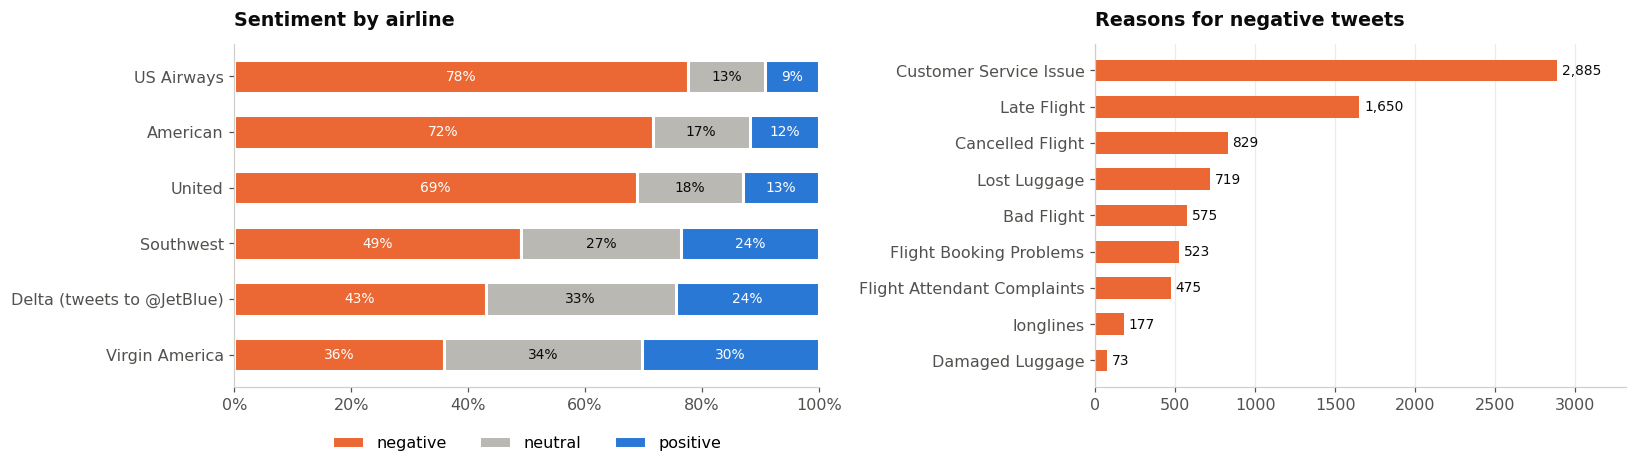

In [12]:
airline_label = df["airline"].replace({"Delta": "Delta (tweets to @JetBlue)"})
by_airline = pd.crosstab(airline_label, df["airline_sentiment"], normalize="index")[CLASSES]
by_airline = by_airline.sort_values("negative")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.1, 1]})
left = np.zeros(len(by_airline))
for label in CLASSES:
    axes[0].barh(by_airline.index, by_airline[label], left=left, color=COLORS[label], height=0.6,
                 label=label, edgecolor="white", linewidth=2)
    for y, (l, v) in enumerate(zip(left, by_airline[label])):
        if v > 0.08:
            axes[0].text(l + v / 2, y, f"{v:.0%}", ha="center", va="center",
                         color="white" if label != "neutral" else INK, fontsize=9)
    left += by_airline[label].values
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1))
axes[0].set_xlim(0, 1)
axes[0].legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.1), frameon=False)
axes[0].set_title("Sentiment by airline")
axes[0].grid(False)

reasons = df["negativereason"].value_counts().drop("Can't Tell").sort_values()
b = axes[1].barh(reasons.index, reasons.values, color=ORANGE, height=0.6)
axes[1].bar_label(b, labels=[f"{v:,}" for v in reasons.values], padding=3, color=INK, fontsize=9)
axes[1].set_xlim(0, reasons.max() * 1.15)
axes[1].set_title("Reasons for negative tweets")
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
plt.savefig("images/airlines_reasons.png")
plt.show()

**Observations:**
- **US Airways, American and United** receive the highest share of negative tweets (69 % to 78 %). **Virgin America** is the best perceived (36 % negative).
- ⚠️ **Data quality issue:** all 1,999 tweets labelled *Delta* are actually addressed to **@JetBlue**. This is a known error in the original dataset, so no conclusion should be drawn about Delta from this data.
- The first cause of complaints is by far **customer service**, before **late flights** and **cancellations**. This is useful for the airlines: the most frequent problem is how customers are handled, not only operations.

## 8. Error Analysis
We look at 5 tweets misclassified by **Linear SVM** (Logistic Regression makes almost the same errors), to understand the limits of word-based models.

In [13]:
errors = pd.DataFrame({
    "text": df.loc[y_test.index, "text"],
    "actual": y_test,
    "predicted": predictions["Linear SVM"],
})
errors = errors[errors["actual"] != errors["predicted"]]
print(f"Misclassified tweets: {len(errors)} of {len(y_test)} ({len(errors) / len(y_test):.1%})")
examples = errors.loc[[6570, 2534, 5056, 7742, 1428]]
examples

Misclassified tweets: 606 of 2897 (20.9%)


,text,actual,predicted
6570,"@SouthwestAir used to love you, but you keep rescheduling my flights. #southworst",negative,positive
2534,@united First Officer of UA 1514 checking our 757 prior to departure from EWR yesterday while on his cell. Safety ??? http://t.co/1TFH2v...,neutral,negative
5056,@SouthwestAir Can you give me info on Flt 681 out of BDL? I see it's Cancelled Flightled.,neutral,negative
7742,@JetBlue thanks. Can you change the music in the boarding gates?,neutral,positive
1428,"@united clicked ""upgrade now"" and it didn't upgrade. What gives? http://t.co/N7oSjz8a59",negative,neutral


**Why did the model fail?**
| # | Tweet (short) | Actual → predicted | Explanation |
|---|---|---|---|
| 1 | *"used to **love** you, but you keep rescheduling my flights #southworst"* | negative → positive | The strong word **"love"** outweighs the rest. A bag-of-words model does not understand the contrast *"used to… but"*, nor the pun *#southworst*. |
| 2 | *"First Officer… checking our 757… while on his cell. **Safety ???**"* | neutral → negative | The tweet clearly expresses concern; the human label "neutral" is **debatable**. Some errors come from **noisy labels**, not from the model. |
| 3 | *"Can you give me info on Flt 681…? I see it's **Cancelled**"* | neutral → negative | It is a **question**, but the word *"cancelled"* is one of the strongest negative signals in the training data. |
| 4 | *"**thanks**. Can you change the music in the boarding gates?"* | neutral → positive | A polite *"thanks"* at the start of a request pushes the prediction to positive. |
| 5 | *"clicked 'upgrade now' and it **didn't upgrade. What gives?**"* | negative → neutral | The frustration is expressed **without typical negative words** and in the form of a question, which the model associates with neutral tweets. |

**Summary:** the model relies on **individual words**. It fails with **sarcasm and contrast** (1), **polite or factual words in the "wrong" class** (3, 4), **implicit frustration** (5), and some labels are themselves questionable (2). Models that read the whole sentence in context (e.g. BERT) handle these cases better.

## 9. Conclusion
- **Best model:** **Logistic Regression** with TF-IDF features — **79.3 % accuracy**, macro F1 = 0.71 — just ahead of Linear SVM (79.1 %) and much better than the rule-based TextBlob (≈ 45 %). It is also the most practical for deployment because it gives a **probability** for each prediction (e.g. send a tweet to an agent only if P(negative) > 0.8).
- The model is **very reliable on negative messages**, which are the most important ones for a customer service team.
- **Real-world application:** an airline (or any company active on social media) could use this model to **automatically sort incoming messages**: send negative tweets to agents first, answer neutral questions with a FAQ or chatbot, and track the **share of negative messages per day** as a customer-satisfaction indicator.

**Limitations and next steps**
- Sarcasm and mixed messages (*"Thanks for the 3-hour delay"*) remain difficult for word-based models.
- The data dates from 2015 and covers only US airlines.
- A **transformer model** (e.g. BERT fine-tuned on tweets) would understand context better and could improve the neutral class.